In [1]:
import numpy as np
import itertools
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [12]:
# noise
noise_vecs = []
noise_vars = []
cosine_sims = []

for i in range(1):
    noise_vec1 = []
    noise_var1 = []
    noise_vec = np.random.randn(64)
    noise_vec = (noise_vec - np.mean(noise_vec)) / np.std(noise_vec)
    noise_vec1.append(noise_vec)
    noise_var1.append(np.var(noise_vec))
    for j in range(63):
        noise_vec = noise_vec + np.random.randn(64)
        noise_vec = (noise_vec - np.mean(noise_vec)) / np.std(noise_vec)
        noise_vec1.append(noise_vec)
        noise_var1.append(np.var(noise_vec))
    noise_vec1 = np.array(noise_vec1)
    noise_vecs.append(noise_vec1)
    noise_vars.append(noise_var1)
    cosine_sims.append(cosine_similarity(noise_vec1))

# print(noise_vecs[0])

noise_vecs = np.mean(noise_vecs, axis=0)
noise_vars = np.mean(noise_vars, axis=0)
cosine_sims = np.mean(cosine_sims, axis=0)



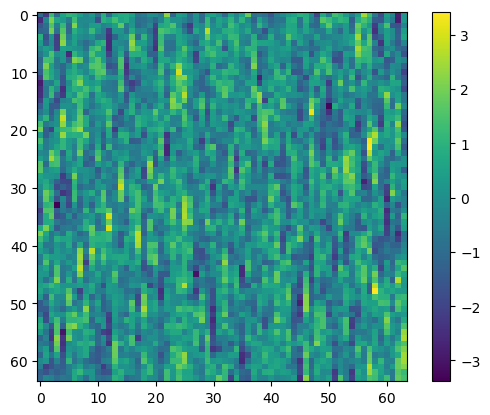

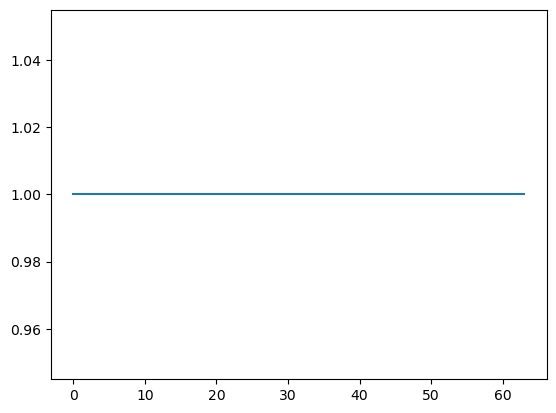

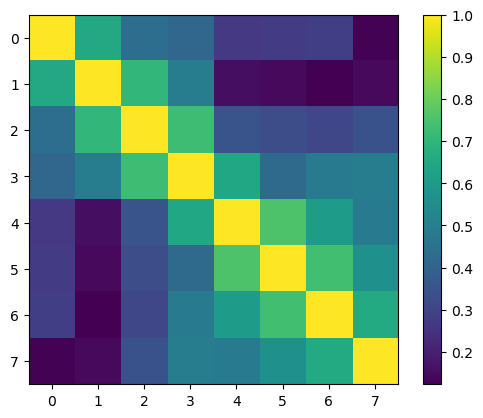

In [58]:


plt.imshow(noise_vecs)
plt.colorbar()
plt.show()
plt.close()

plt.plot(noise_vars)
plt.show()
plt.close()

plt.imshow(cosine_sims[:8, :8])
plt.colorbar()
plt.show()
plt.close()

In [65]:
dim = 64
x = np.linspace(-3, 3+6/(dim-2)*((int(dim)+1) % 2), dim)
sigma = 0.4
std = 0.4
gaussian_vec = (1.0 / np.sqrt(2 * np.pi * sigma ** 2)) * np.exp(-0.5 * (x / sigma) ** 2)
gaussian_vec = (gaussian_vec - np.mean(gaussian_vec)) / np.std(gaussian_vec) * std
print(np.std(gaussian_vec))
gaussian_vec = np.roll(gaussian_vec, -63//2)
gaussian_vecs = []
for i in range(63):
    gaussian_vec = np.roll(gaussian_vec, 1)
    gaussian_vecs.append(gaussian_vec)
gaussian_vecs = np.array(gaussian_vecs)

cosine_sims = cosine_similarity(gaussian_vecs)
print(gaussian_vecs[0])

0.39999999999999997
[ 1.12842225  1.08958949  0.97968307  0.81664883  0.62499511  0.4297971
  0.25150081  0.10293713 -0.01108335 -0.09217295 -0.14582625 -0.17894626
 -0.19805924 -0.20838616 -0.21361644 -0.21610181 -0.21721068 -0.21767548
 -0.2178586  -0.21792644 -0.21795009 -0.21795784 -0.21796023 -0.21796093
 -0.21796112 -0.21796116 -0.21796118 -0.21796118 -0.21796118 -0.21796118
 -0.21796118 -0.21796118 -0.21796118 -0.21796118 -0.21796118 -0.21796118
 -0.21796118 -0.21796118 -0.21796118 -0.21796116 -0.21796112 -0.21796093
 -0.21796023 -0.21795784 -0.21795009 -0.21792644 -0.2178586  -0.21767548
 -0.21721068 -0.21610181 -0.21361644 -0.20838616 -0.19805924 -0.17894626
 -0.14582625 -0.09217295 -0.01108335  0.10293713  0.25150081  0.4297971
  0.62499511  0.81664883  0.97968307  1.08958949]


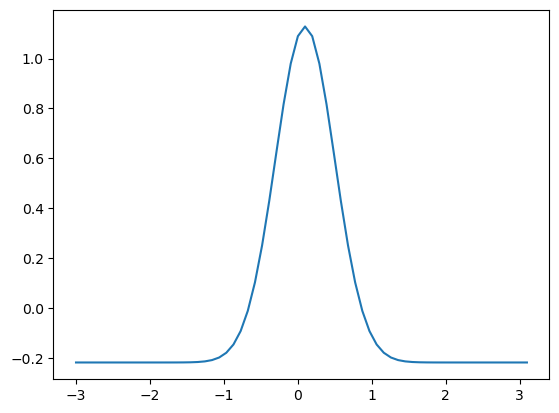

62


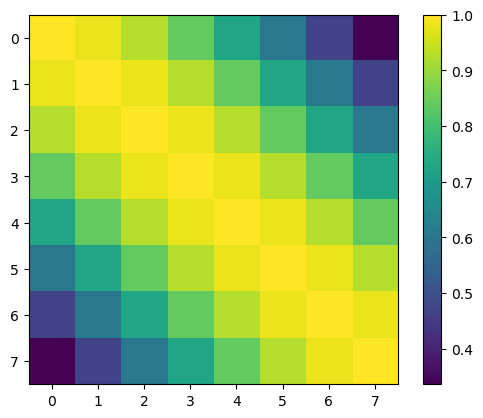

In [ ]:
plt.plot(x, gaussian_vecs[dim //2])
plt.show()
plt.close()
print(np.argmax(gaussian_vecs[-1]))

plt.imshow(cosine_sims[:8, :8])
plt.colorbar()
plt.show()
plt.close()

[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]


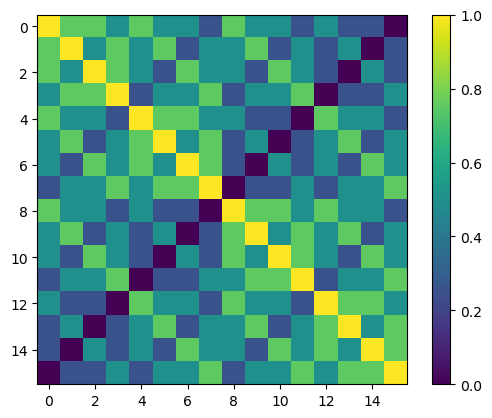

In [20]:
feature_dim = 2
num_features = 4
item_features = list(itertools.product(range(feature_dim), repeat=num_features))
item_features = np.array(item_features)
print(item_features)

item_vecs = []
for i in range(len(item_features)):
    vec = np.zeros(feature_dim * num_features)
    for j in range(num_features):
        vec[j * feature_dim + item_features[i, j]] = 1
    item_vecs.append(vec)
item_vecs = np.array(item_vecs)

cosine_sims = cosine_similarity(item_vecs)
plt.imshow(cosine_sims)
plt.colorbar()
plt.show()
plt.close()


In [11]:
import numpy as np
import random
from copy import deepcopy

class HierarchicalBinaryPatterns(object):

    def __init__(self, dim=32, n1=4, n2=4, n3=4, p1=.2, p2=.05):
        self.dim = dim
        self.n1 = n1
        self.n2 = n2
        self.n3 = n3
        self.p1 = p1
        self.p2 = p2
        # useful constants
        self.n = n1 * n2 * n3
        self.relation_matrix = create_block_matrix(self.n, n1) + create_block_matrix(self.n, n1*n2) + np.eye(self.n)
        # gen data
        A = np.round(np.random.uniform(size=(n1, dim)))
        Aij = np.zeros((n1, n2, dim))
        Aijk = np.zeros((n1, n2, n3, dim))
        for i in range(n1):
            for j in range(n2):
                Aij[i, j] = random_flip(p1, deepcopy(A[i]))
                for k in range(n3):
                    Aijk[i,j,k] = random_flip(p2, deepcopy(Aij[i, j]))
        self.data = Aijk.reshape((-1, dim))

    def get_data(self):
        return self.data


def random_flip(p, vector):
    """
    Flips p percent of the entries in a binary-valued vector.

    :param p: float, percentage of entries to flip (between 0 and 100)
    :param vector: list or numpy array of binary values (0s and 1s)
    :return: modified vector with p percent of entries flipped
    """
    if not 0 <= p <= 1:
        raise ValueError("Percentage p must be between 0 and 100")

    num_to_flip = int(np.round(len(vector) * p))
    indices_to_flip = random.sample(range(len(vector)), num_to_flip)

    for index in indices_to_flip:
        vector[index] = 1 - vector[index]  # Flip the value (0->1, 1->0)

    return vector

def create_block_matrix(m, n):
    """
    Creates an m x m block matrix with n blocks of ones along the diagonal.

    :param m: The size of the matrix (number of rows and columns).
    :param n: The number of blocks of ones along the diagonal.
    :return: An m x m numpy array representing the block matrix.

    # Example usage
    m = 6
    n = 2
    block_matrix = create_block_matrix(m, n)
    print(block_matrix)
    """
    if n > m:
        raise ValueError("Number of blocks cannot be greater than the matrix size.")

    # Initialize an m x m matrix of zeros
    matrix = np.zeros((m, m))

    # Calculate the size of each block
    block_size = m // n

    # Fill diagonal blocks with ones
    for i in range(n):
        start_index = i * block_size
        end_index = start_index + block_size
        matrix[start_index:end_index, start_index:end_index] = np.ones((block_size, block_size))

    return matrix

0.494140625


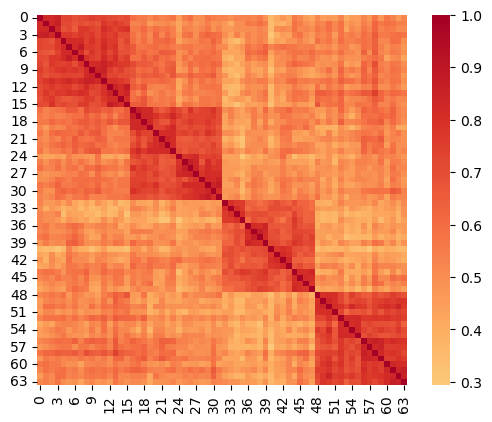

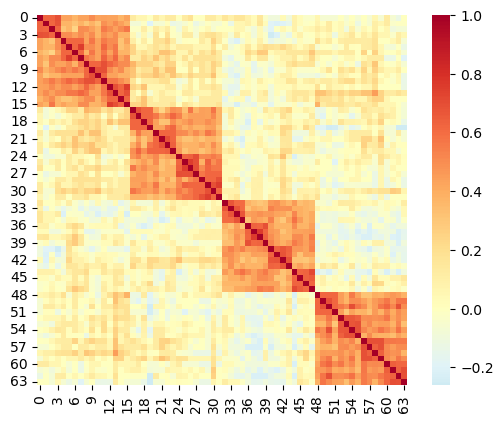

In [12]:
import seaborn as sns

# '''generate patterns with 2 levels of Hierarchy
#     4 level 1 nodes - prototypes
#     4 leafs per prototypes
#     4x4 = 16 instances in total
# '''
# dim = 64
# n1 = 4
# n2 = 1
# n3 = 4
# p1 = 0
# p2 = .1

# bup = HierarchicalBinaryPatterns(dim=dim, n1=n1,n2=n2,n3=n3, p1=p1, p2=p2)

# f, ax = plt.subplots()
# RSM = np.corrcoef(bup.data)
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

# f, ax = plt.subplots()
# RSM = np.corrcoef(bup.data)
# sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)


'''generate patterns with 3 levels of Hierarchy
    4 level 1 nodes - prototypes
    4 level 2 nodes per every prototype
    4 level 3 nodes / leafs per level 2 node
    4x4x4 = 64 instances in total
'''
dim = 64
n1 = 4
n2 = 4
n3 = 4
p1 = .1
p2 = .1

bup = HierarchicalBinaryPatterns(dim=dim, n1=n1,n2=n2,n3=n3, p1=p1, p2=p2)

f, ax = plt.subplots()
RSM = np.corrcoef(bup.data)
RSM = cosine_similarity(bup.data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

f, ax = plt.subplots()
RSM = np.corrcoef(bup.data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

print(np.mean(bup.data))

(64, 64)
0.482421875


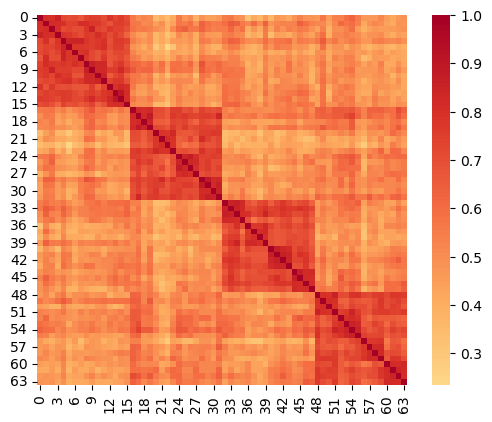

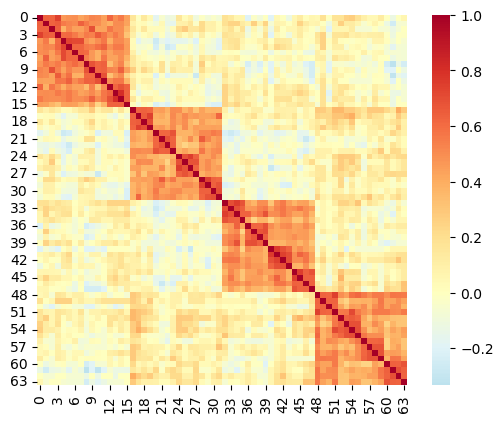

In [15]:
from tasks.utils import hierarchical_binary_patterns

relation_matrix, data = hierarchical_binary_patterns(dim=64, n1=4, n2=4, n3=4, p1=.1, p2=.1)

print(data.shape)

f, ax = plt.subplots()
RSM = np.corrcoef(data)
RSM = cosine_similarity(data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

f, ax = plt.subplots()
RSM = np.corrcoef(data)
sns.heatmap(RSM, square=True, cmap='RdYlBu_r', center=0)

print(np.mean(data))

np.save("./data/hierarchical_binary_patterns.npy", data)

In [ ]:
from tasks import FreeRecall

env = FreeRecall(num_features=4, feature_dim=2, sequence_len=4, retrieve_time_limit=None, reset_state_before_test=True, 
                correct_reward=1.0, wrong_reward=-1.0, no_action_reward=-1.0, 
                include_condition_during_encode=False, one_hot_stimuli=True, one_hot_action=True, 
                gaussian_stimuli=False, gaussian_stimuli_std=1.0, gaussian_stimuli_sigma=0.2, 
                include_extra_observation=True, extra_observation_type="gaussian", extra_observation_dim=11, 
                requires_extra_action=False, include_extra_observation_during_recall=True, different_extra_observation_during_recall=False, seed=None)

done = False
obs, info = env.reset()
t = 0
print("time step: ", t)
print(obs, info)
while not done:
    action = env.action_space.sample()
    obs, reward, _, _, info = env.step(action)
    done = info["done"]
    print("action: ", action, "reward: ", reward)
    print()
    t += 1
    print("time step: ", t)
    print(obs, info)



time step:  0
[ 0.          0.          1.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.32393819 -0.32393819
 -0.32393814 -0.28521366  3.16193276 -0.28521366 -0.32393814 -0.32393819
 -0.32393819 -0.32393819 -0.32393819  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ] {'phase': 'encoding'}
action:  [12] reward:  0.0

time step:  1
[ 0.          0.          0.          0.          1.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -0.32393819 -0.32393819
 -0.32393819 -0.32393814 -0.28521366  3.16193276 -0.28521366 -0.32393814
 -0.32393819 -0.32393819 -0.32393819  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ] {'phase': 'encoding', 'gt': array([3.]), 'gt_mask': True, 'loss_mask': True, 'corr